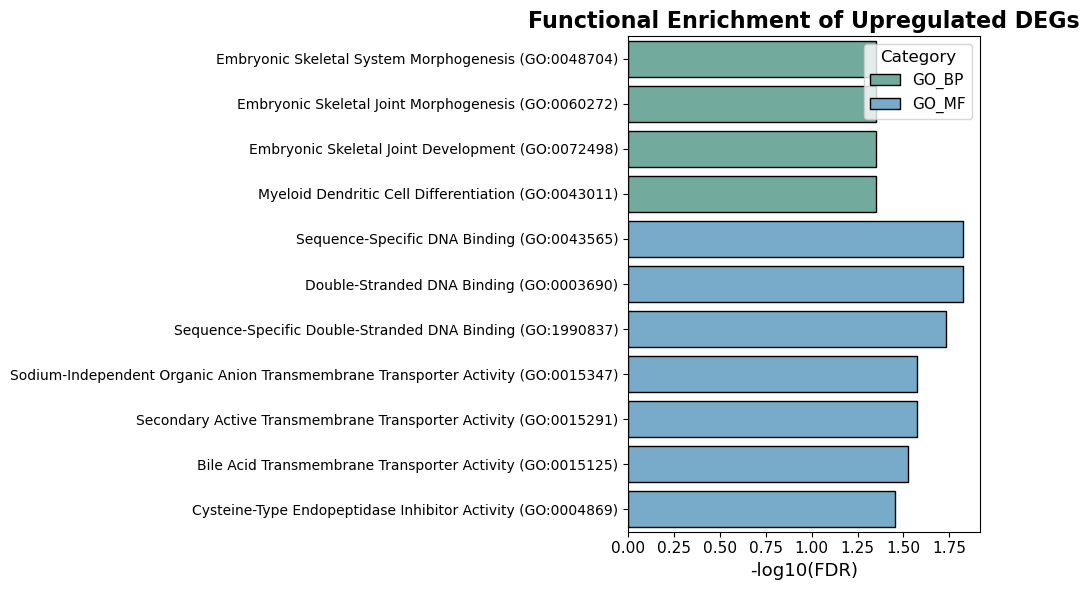

✅ Plot saved to: C:\Users\Neg\TCGA_GC_project\Functional_Analysis\manual\ENRICHR\Up_85\Upregulated_Combined_Enrichment_BarPlot.png


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set input and output directories
input_dir = r"C:\Users\Neg\TCGA_GC_project\Functional_Analysis\manual\ENRICHR\Up_85"
output_path = os.path.join(input_dir, "Upregulated_Combined_Enrichment_BarPlot.png")

# Define files and their source labels
files_sources = {
    "GO_Biological_Process_2025_table.txt": "GO_BP",
    "GO_Cellular_Component_2025_table.txt": "GO_CC",
    "GO_Molecular_Function_2025_table.txt": "GO_MF",
    "Reactome_Pathways_2024_table.txt": "Reactome"
}

# List to collect processed data
merged_data = []

# Load and process each file
for filename, source in files_sources.items():
    file_path = os.path.join(input_dir, filename)
    df = pd.read_csv(file_path, sep="\t")
    
    if "Adjusted P-value" not in df.columns or "Term" not in df.columns:
        print(f"Skipping {filename}: missing required columns.")
        continue

    # Filter by FDR and compute -log10(FDR)
    df = df[df["Adjusted P-value"] < 0.05].copy()
    df["-log10(FDR)"] = -np.log10(df["Adjusted P-value"])
    df["Source"] = source
    merged_data.append(df[["Term", "-log10(FDR)", "Source"]].head(10))

# Merge all
plot_df = pd.concat(merged_data, ignore_index=True)

# Color mapping
palette = {
    "GO_BP": "#69b3a2",
    "GO_CC": "#a377d2",
    "GO_MF": "#6aaed6",
    "Reactome": "#f8766d"
}

# Plotting
plt.figure(figsize=(10, max(6, 0.5 * len(plot_df))))
sns.barplot(
    data=plot_df,
    y="Term",
    x="-log10(FDR)",
    hue="Source",
    dodge=False,
    palette=palette,
    edgecolor='black'
)

# Styling
plt.title("Functional Enrichment of Upregulated DEGs", fontsize=16, weight='bold')
plt.xlabel("-log10(FDR)", fontsize=13)
plt.ylabel("")
plt.legend(title="Category", title_fontsize=12, fontsize=11, loc='best')
plt.xticks(fontsize=11)
plt.yticks(fontsize=10)
plt.tight_layout()

# Save plot
plt.savefig(output_path, dpi=600)
plt.show()

print(f"✅ Plot saved to: {output_path}")


In [14]:
from PIL import Image

# File paths
input_path = r"C:\Users\Neg\TCGA_GC_project\Manuscript\GO_Pathway_Up_85.tif"
output_path = r"C:\Users\Neg\TCGA_GC_project\Manuscript\GO_Pathway_Up_85_600dpi.tif"

# Open the image
img = Image.open(input_path)

# Optional: upscale image size (e.g., 2x larger)
scale_factor = 2
new_size = (img.width * scale_factor, img.height * scale_factor)
img_resized = img.resize(new_size, Image.LANCZOS)

# Save with high DPI
img_resized.save(output_path, dpi=(600, 600))

print(f"✅ High-resolution image saved to: {output_path}")


✅ High-resolution image saved to: C:\Users\Neg\TCGA_GC_project\Manuscript\GO_Pathway_Up_85_600dpi.tif


In [8]:
pip install pillow


Note: you may need to restart the kernel to use updated packages.


In [2]:
from PIL import Image, ImageDraw, ImageFont
import os

# Input directory and file names
folder = r"C:\Users\Neg\TCGA_GC_project\Functional_Analysis\manual\ENRICHR\Up_85"
filenames = [
    "GO_Biological_Process_2025_bar_graph.jpg",
    "GO_Cellular_Component_2025_bar_graph.jpg",
    "GO_Molecular_Function_2025_bar_graph.jpg",
    "Reactome_Pathways_2024_bar_graph.jpg"
]

# Corresponding labels for panels
labels = ['A', 'B', 'C', 'D']

# Load all images
images = [Image.open(os.path.join(folder, fname)) for fname in filenames]

# Resize all images to the same dimensions (optional but safer)
base_width = max(img.width for img in images)
base_height = max(img.height for img in images)
images = [img.resize((base_width, base_height), Image.LANCZOS) for img in images]

# Create blank canvas for 2x2 grid
margin = 50
grid_width = 2 * base_width + 3 * margin
grid_height = 2 * base_height + 3 * margin
canvas = Image.new("RGB", (grid_width, grid_height), color="white")

# Paste images with spacing and label them
positions = [
    (margin, margin),
    (base_width + 2 * margin, margin),
    (margin, base_height + 2 * margin),
    (base_width + 2 * margin, base_height + 2 * margin)
]

# Add labeled images
draw = ImageDraw.Draw(canvas)
try:
    font = ImageFont.truetype("arial.ttf", 40)
except:
    font = ImageFont.load_default()

for i, (img, pos, label) in enumerate(zip(images, positions, labels)):
    canvas.paste(img, pos)
    draw.text((pos[0], pos[1] - 40), f"{label}", font=font, fill="black")

# Save final merged figure
output_path = os.path.join(folder, "Upregulated_Combined_Enrichment_Figure.jpg")
canvas.save(output_path, dpi=(600, 600))

print(f"✅ Combined figure saved to: {output_path}")


✅ Combined figure saved to: C:\Users\Neg\TCGA_GC_project\Functional_Analysis\manual\ENRICHR\Up_85\Upregulated_Combined_Enrichment_Figure.jpg
